_Células em Markdown foram traduzidas por mim, cometários originais feitos nas células de código._

### Principal Component Analysis

PCA é uma técnica de redução de dimensionalidade, ela permite sintetizar os dados multi dimensionais para dimensões menores, selecionando novas dimensões que preservem o máximo possível da variância dos dados.

Um exemplo de caso de uso de PCA para não fugir da realidade: Uma imagem em preto e branco ela contém três dimensões de dados, posição no eixo X, posição no eixo Y e o brilho em cada ponto. Sintentizar isso para duas dimensões pode ser utilizado para coisas como compressão de imagem ou reconhecimento facial, pois sintetiza com base nas informações que mais representam o conjunto de dados.

Vamos fazer isso com um exemplo mais simples: O conjunto de dados Iris (_the Iris dataset_) que está disponível no scikit-learn. É apenas uma pequena coleção de dados que possuem quatro dimensões de dados de três diferentes tipos de flores de Iris: O comprimento e tamanho tanto das pétalas quanto das sépalas individiduais de cada flor de cada espécie. Vamos carregar os dados e dar uma olhada:

In [1]:
from sklearn.datasets import load_iris # Utilizada para carregar o `Iris dataset`
from sklearn.decomposition import PCA # Objeto configurado para realizar a redução de dimensionalidade utilizando PCA
import pylab as pl # Pacote do MatPlotLib
from itertools import cycle

iris = load_iris() # Carrega o `Iris dataset`

numSamples, numFeatures = iris.data.shape
print(numSamples) # Quantidade da flores no conjunto
print(numFeatures) # Quantidade de características, ou seja o número de dimensões que existem ao analisar os elementos.
print(list(iris.target_names)) # Tipos de flores presentes

150
4
[np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


Isso nos diz que os dados são compostos por 150 amostras (flores individuais), Possui 4 dimensões chamadas de 
_features_ e três tipos diferentes de flores de Iris classificadas neles.

Enquanto visualizar dados com 2 ou até 3 dimensões é fácil, visualizar dados em 4 dimensões é algo que nossos cérebros não podem
fazer. Então vamos sintentizar esses dados em 2 dimensões e ver como isso fica:

In [2]:
X = iris.data # Acessa os dados do _dataset_
pca = PCA(n_components=2, whiten=True).fit(X) # `n_components` representa o número de dimensões a ser reduzido
                                                # e `whiten` indica se os dados devem ser normalizados ou não, `True`
                                                # para que seja normalizado.
                                                # `fit` ajusta com base nos dados de X.
X_pca = pca.transform(X) # Realiza a redução de dimensionalidade utilizando PCA.

O que fizemos foi sintetizar os dados de 4D para 2D, ao projetar de maneira reduzida dois vetores ortogonais
de 4 dimensões que servem de base para a nova projeção 2D. Nós podemos ver o que esses vetores 4D são apsar de não ser algo que podemos imaginar de cabeça.

In [3]:
print(pca.components_) # Mostra os dois vetores em 4D os chamados _eigenvectors_

[[ 0.36138659 -0.08452251  0.85667061  0.3582892 ]
 [ 0.65658877  0.73016143 -0.17337266 -0.07548102]]


Vamos ver o quanto de informação conseguimos manter:

In [4]:
print(pca.explained_variance_ratio_) # Quanto cada dimensão manteve de representação do conjunto 4D.
print(sum(pca.explained_variance_ratio_)) # Soma para saber o total preservado

[0.92461872 0.05306648]
0.9776852063187945


Isso é muito interessante! Apesar de ter jogado fora duas das quatro dimensões, PCA escolheu às duas dimensões
restantes muito bem tanto que manteve 92% da variância dos dados em uma dimensão sozinha. A segunda dimensão apenas nos dá um adicional de 5%; Ao todo nós perdemos apenas 3% da variância nos dados ao reduziar a projeção para duas dimensões.

Como prometido, agora que temos uma representação em 2D dos dados, nós podemos projetá-los:

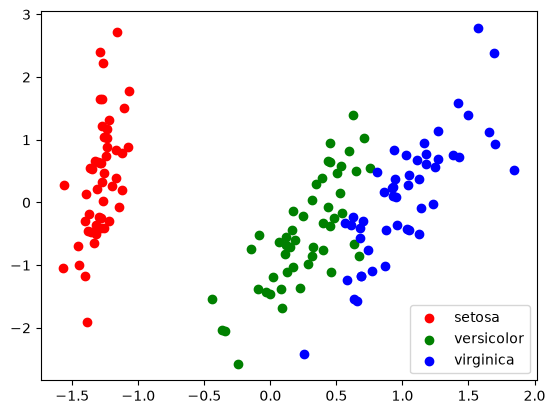

In [5]:
colors = cycle('rgb') # cria um iterável com os valores informados até acabar.
target_ids = range(len((iris.target_names))) # Ids para os tipos
pl.figure() # Inicia uma figura para visualização
for i, c, label in zip(target_ids, colors, iris.target_names): # `zip` transforma cada elemento do arranjo em uma tuplas
                                                                # retornando uma lista de tuplas.
    pl.scatter(X_pca[iris.target == i, 0], X_pca[iris.target == i, 1], # Para cada tipo de espécie monta um `scatter 
                                                                       # plot` com as duas dimensões (0 e 1, X e Y).
                   c=c, label=label)

pl.legend() # Mostra a legenda
pl.show()

Você pode ver que há diferentes tipos de Iris que estão agrupadas muito bem. Se pensar sobre, isso provavelmente
funciona bem por conta do tamanho geral de uma flor contribuir para que o tamanho das pétalas e sépals cresçam de maneira semelhante.
Apesar dos números nesse gráfico não terem um significado intuitivo, nós provavelmente estamos vendo a medida comparativa (_ratio_) do tamanho e altura par pétalas e sépalas - e PCA sintetizou os dados por conta própria.

### Atividade

Nossos resultados sugerem que poderáimos ter reduzido os dados para uma dimensão a mesmo assim preservar a maioria da variância.
Tente isso! Faça um PCA reduzindo para uma dimensão é meça os resultados.

[[ 0.36138659 -0.08452251  0.85667061  0.3582892 ]]
[0.92461872]


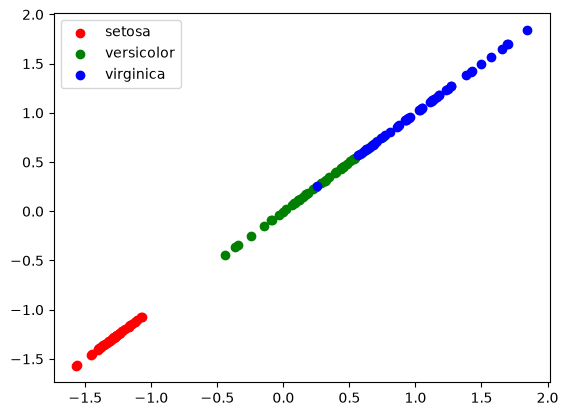

In [6]:
y = iris.data # Atribuindo os dados novamente.
pca = PCA(n_components=1, whiten=True).fit(y) # Configura o PCA para reudizar a uma dimensão
y_pca = pca.transform(y) 

print(pca.components_) # Mostra o que foi utilizado como base pelo PCA.

print(pca.explained_variance_ratio_) # Manteve a variância de 92%. Ao invés da de 97%.

colors = ['r', 'g', 'b']
target_ids = range(len(iris.target_names))
pl.figure()
for i, c, label in zip(target_ids, colors, iris.target_names):
    pl.scatter(y_pca[iris.target == i, 0], y_pca[iris.target == i, 0], c=c, label=label) # Mostrando o gráfico de disperão 
                                                                                        # onde X e Y são iguais
                                                                                        # no caso de para uma dimensão.

pl.legend()
pl.show()